In [1]:
import numpy as np
import cobaya
from cobaya.yaml import yaml_load

In [2]:
info_txt = r"""
likelihood:
#    sn: import_module('likelihood').snlike
    cc: import_module('likelihood').cclike
    bao: import_module('likelihood').baolike
params:      
    H0: 
        prior: {min: 60,  max: 80}
        latex: H_0
    q0: 
        prior: {min: -1, max: 1}
        latex: q_0
    j0: 
        prior: {min: -20, max: 5}
        latex: j_0
    s0: 
        prior: {min: -170, max: 10}
        latex: s_0
force: True
sampler:
    mcmc:
        burn_in: 100
        max_tries: 50000
        max_samples: 50000
        learn_proposal: True

output: ../chains/cb
"""

info_HW = yaml_load(info_txt)

In [3]:
from cobaya.run import run
updated_info, products = run(info_HW)

[output] Output to be read-from/written-into folder '../chains', with prefix 'cb'
[cc] Initialized external likelihood.
[bao] Initialized external likelihood.
[mcmc] Getting initial point... (this may take a few seconds)
[prior] Reference values or pdfs for some parameters were not provided. Sampling from the prior instead for those parameters.
[model] Measuring speeds... (this may take a few seconds)
[model] Setting measured speeds (per sec): {cc: 19400.0, bao: 13800.0}
[mcmc] Initial point: H0:63.93817, q0:0.7837873, j0:-8.665846, s0:-87.31486
[prior] *WARNING* Reference pdf not defined or improper for some parameters. Using prior's sigma instead for them.
[mcmc] Covariance matrix not present. We will start learning the covariance of the proposal earlier: R-1 = 30 (would be 2 if all params loaded).
[mcmc] Sampling! (NB: no accepted step will be saved until 100 burn-in samples have been obtained)
[mcmc] Progress @ 2026-10-04 16:26:44 : 1 steps taken -- still burning in, 100 accepted s

/home/alan/workspace/0TEST/NEW/code/likelihood.py:39: RuntimeWarning: invalid value encountered in scalar power
  dV = (c * z * dl**2 / (1. + z)**2 / Hz) ** (1./3.)


[mcmc] Finished burn-in phase: discarded 100 accepted steps.
[mcmc] Learn + convergence test @ 160 samples accepted.
[mcmc]  - Acceptance rate: 0.007
[mcmc]  - Convergence of means: R-1 = 2.429044 after 128 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 320 samples accepted.
[mcmc]  - Acceptance rate: 0.019
[mcmc]  - Convergence of means: R-1 = 2.281581 after 256 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 480 samples accepted.
[mcmc]  - Acceptance rate: 0.039
[mcmc]  - Convergence of means: R-1 = 1.875199 after 384 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 640 samples accepted.
[mcmc]  - Acceptance rate: 0.092
[mcmc]  - Convergence of means: R-1 = 0.168230 after 512 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 800 samples accepted.
[mcmc]  - Acceptance rate: 

[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 6240 samples accepted.
[mcmc]  - Acceptance rate: 0.235
[mcmc]  - Convergence of means: R-1 = 0.072600 after 4992 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 6400 samples accepted.
[mcmc]  - Acceptance rate: 0.235
[mcmc]  - Convergence of means: R-1 = 0.089434 after 5120 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 6560 samples accepted.
[mcmc]  - Acceptance rate: 0.234
[mcmc]  - Convergence of means: R-1 = 0.090083 after 5248 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 6720 samples accepted.
[mcmc]  - Acceptance rate: 0.233
[mcmc]  - Convergence of means: R-1 = 0.072193 after 5376 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 6880 samples accepted.
[mcmc]  - Acceptance rate:

[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 12320 samples accepted.
[mcmc]  - Acceptance rate: 0.214
[mcmc]  - Convergence of means: R-1 = 0.027719 after 9856 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 12480 samples accepted.
[mcmc]  - Acceptance rate: 0.214
[mcmc]  - Convergence of means: R-1 = 0.029758 after 9984 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 12640 samples accepted.
[mcmc]  - Acceptance rate: 0.213
[mcmc]  - Convergence of means: R-1 = 0.027706 after 10112 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 12800 samples accepted.
[mcmc]  - Acceptance rate: 0.213
[mcmc]  - Convergence of means: R-1 = 0.028083 after 10240 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 12960 samples accepted.
[mcmc]  - Acceptanc

[root] *WARNING* outlier fraction 0.0026785714285714286 


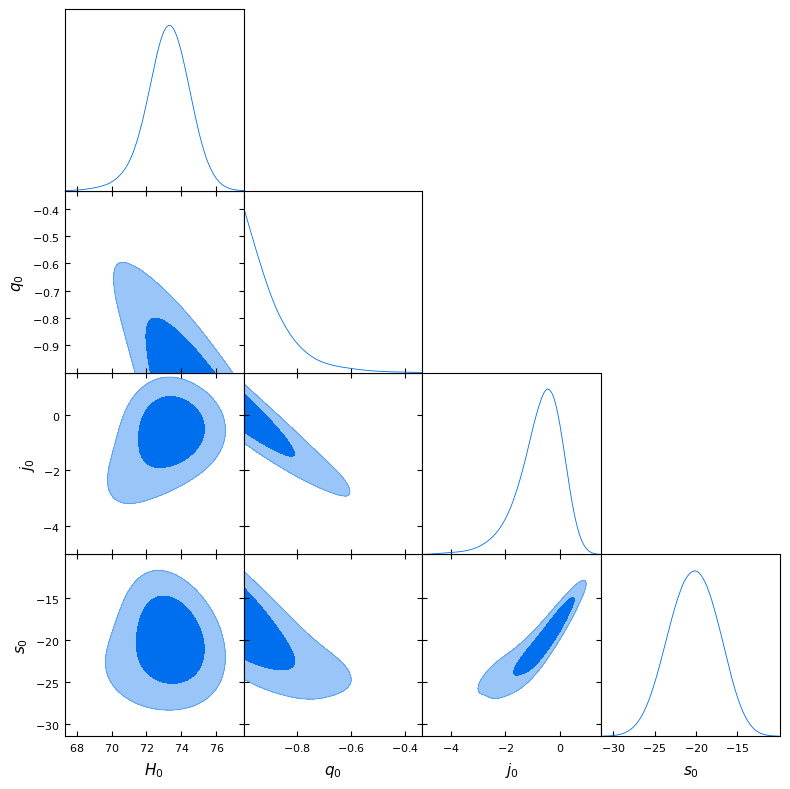

In [4]:
from getdist.mcsamples import MCSamplesFromCobaya
import getdist.plots as gdplt

gd_sample = MCSamplesFromCobaya(updated_info, products.products()["sample"])

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, ["H0", "q0", "j0", "s0"], filled=True)
gdplot.export()

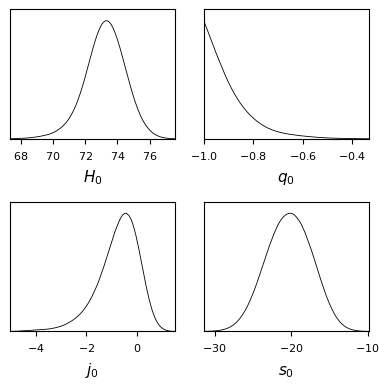

In [5]:
gdplot.plots_1d(gd_sample, ["H0", "q0", "j0", "s0"])
gdplot.export()

In [6]:
# Default limits are 1: 68%, 2: 95%, 3: 99% probability enclosed
print("\n68% limits:\n")
print(gd_sample.getInlineLatex('H0',limit=1))
print(gd_sample.getInlineLatex('q0',limit=1))
print(gd_sample.getInlineLatex('j0',limit=1))
print(gd_sample.getInlineLatex('s0',limit=1))


68% limits:

H_0 = 73.3^{+1.1}_{-0.98}
q_0 < -0.885
j_0 = -0.71^{+0.91}_{-0.58}
s_0 = -20.3\pm 2.9
